In [1]:
# importação de bibliotecas

import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
sns.set_theme(style="whitegrid", palette="viridis")


#Analise exploratoria de dados


In [2]:
imob = pd.read_csv('dataset_2.csv')

In [3]:
imob.head()


,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


In [4]:
imob.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1091 non-null   float64
 1   Rooms          1091 non-null   float64
 2   Build_Year     1124 non-null   int64  
 3   Location       1124 non-null   object 
 4   Street_Type    1124 non-null   object 
 5   Furnishing     1091 non-null   object 
 6   Property_Type  1124 non-null   object 
 7   Has_Pool       1124 non-null   object 
 8   Price          1124 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 79.2+ KB


In [5]:
imob.isna().sum()

Area_SqFt        33
Rooms            33
Build_Year        0
Location          0
Street_Type       0
Furnishing       33
Property_Type     0
Has_Pool          0
Price             0
dtype: int64

In [6]:
linhas_vazias_sqrt = imob[imob['Area_SqFt'].isna()].index

In [7]:
linhas_vazias_rooms = imob[imob['Rooms'].isna()].index

In [8]:
linhas_vazias_furnishing = imob[imob['Furnishing'].isna()].index

In [9]:
linhas_vazias_sqrt
linhas_vazias_furnishing
linhas_vazias_rooms

Index([  56,   87,  118,  125,  127,  157,  171,  182,  186,  274,  308,  348,
        382,  394,  417,  451,  454,  482,  648,  651,  783,  798,  898,  912,
        947,  976,  977,  990, 1017, 1025, 1044, 1057, 1093],
      dtype='int64')

In [10]:
linhas_vazias_rooms


Index([  56,   87,  118,  125,  127,  157,  171,  182,  186,  274,  308,  348,
        382,  394,  417,  451,  454,  482,  648,  651,  783,  798,  898,  912,
        947,  976,  977,  990, 1017, 1025, 1044, 1057, 1093],
      dtype='int64')

In [11]:


# Comparando se são exatamente as mesmas linhas
sao_iguais = linhas_vazias_sqrt.equals(linhas_vazias_rooms)
print("As linhas vazias são as mesmas?", sao_iguais)


As linhas vazias são as mesmas? False


In [12]:
imob.dropna(subset=['Area_SqFt', 'Rooms', 'Furnishing'], inplace=True)

In [13]:
imob.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1027 entries, 0 to 1123
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Area_SqFt      1027 non-null   float64
 1   Rooms          1027 non-null   float64
 2   Build_Year     1027 non-null   int64  
 3   Location       1027 non-null   object 
 4   Street_Type    1027 non-null   object 
 5   Furnishing     1027 non-null   object 
 6   Property_Type  1027 non-null   object 
 7   Has_Pool       1027 non-null   object 
 8   Price          1027 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 80.2+ KB


In [14]:
imob.isna().sum()

Area_SqFt        0
Rooms            0
Build_Year       0
Location         0
Street_Type      0
Furnishing       0
Property_Type    0
Has_Pool         0
Price            0
dtype: int64

In [15]:
imob.describe()

,Area_SqFt,Rooms,Build_Year,Price
count,1027.000000,1027.000000,1027.000000,1.027000e+03
mean,2238.749462,4.566699,2005.081792,6.098391e+05
std,744.704478,1.676631,11.791113,1.450773e+05
min,700.000000,2.000000,1985.000000,2.486400e+05
25%,1826.724874,3.000000,1995.000000,5.177645e+05
50%,2206.565229,5.000000,2005.000000,6.032640e+05
75%,2578.977535,6.000000,2015.000000,6.897460e+05
max,10267.124330,7.000000,2024.000000,2.071402e+06


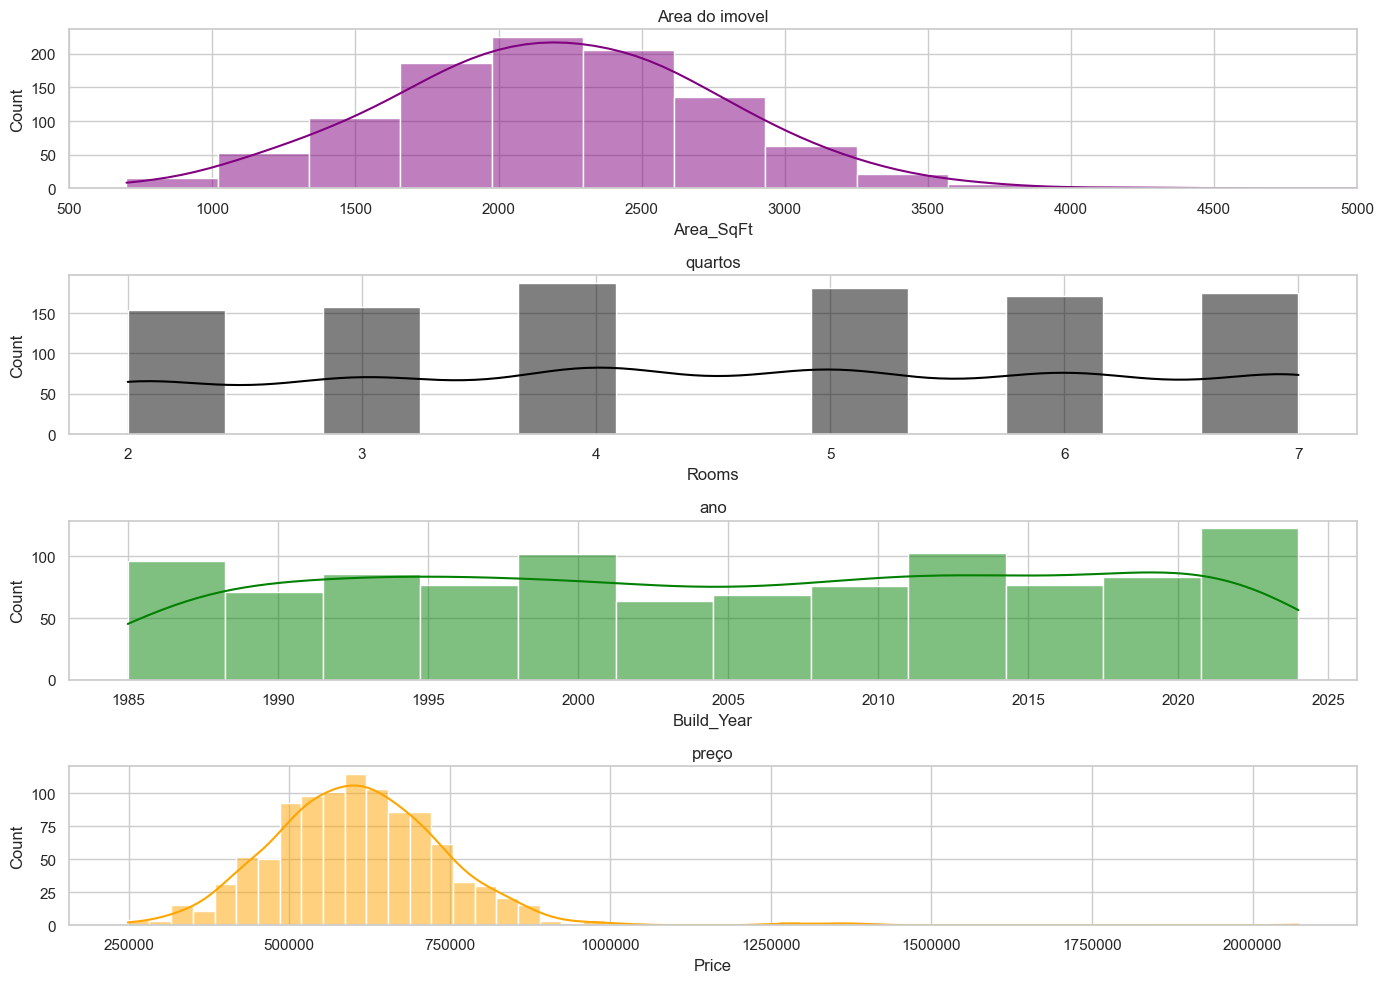

In [16]:
#visualizando dados

plt.figure(figsize=(14,10))
plt.subplot(4,1,1)
sns.histplot(data=imob, x='Area_SqFt', bins=30, kde = True, color = 'purple')
plt.xlim(500,5000)
plt.title('Area do imovel')
plt.subplot(4,1,2)
sns.histplot(data = imob, x = 'Rooms', kde=True, color = 'black')
plt.title('quartos')
plt.subplot(4,1,3)
sns.histplot(data = imob, x = 'Build_Year', kde = True, color = 'green')
plt.title('ano')
plt.subplot(4,1,4)
sns.histplot(data = imob, x = 'Price', kde=True, color='orange')
plt.ticklabel_format(style='plain', axis='x')
plt.title('preço')
plt.tight_layout()
plt.show()

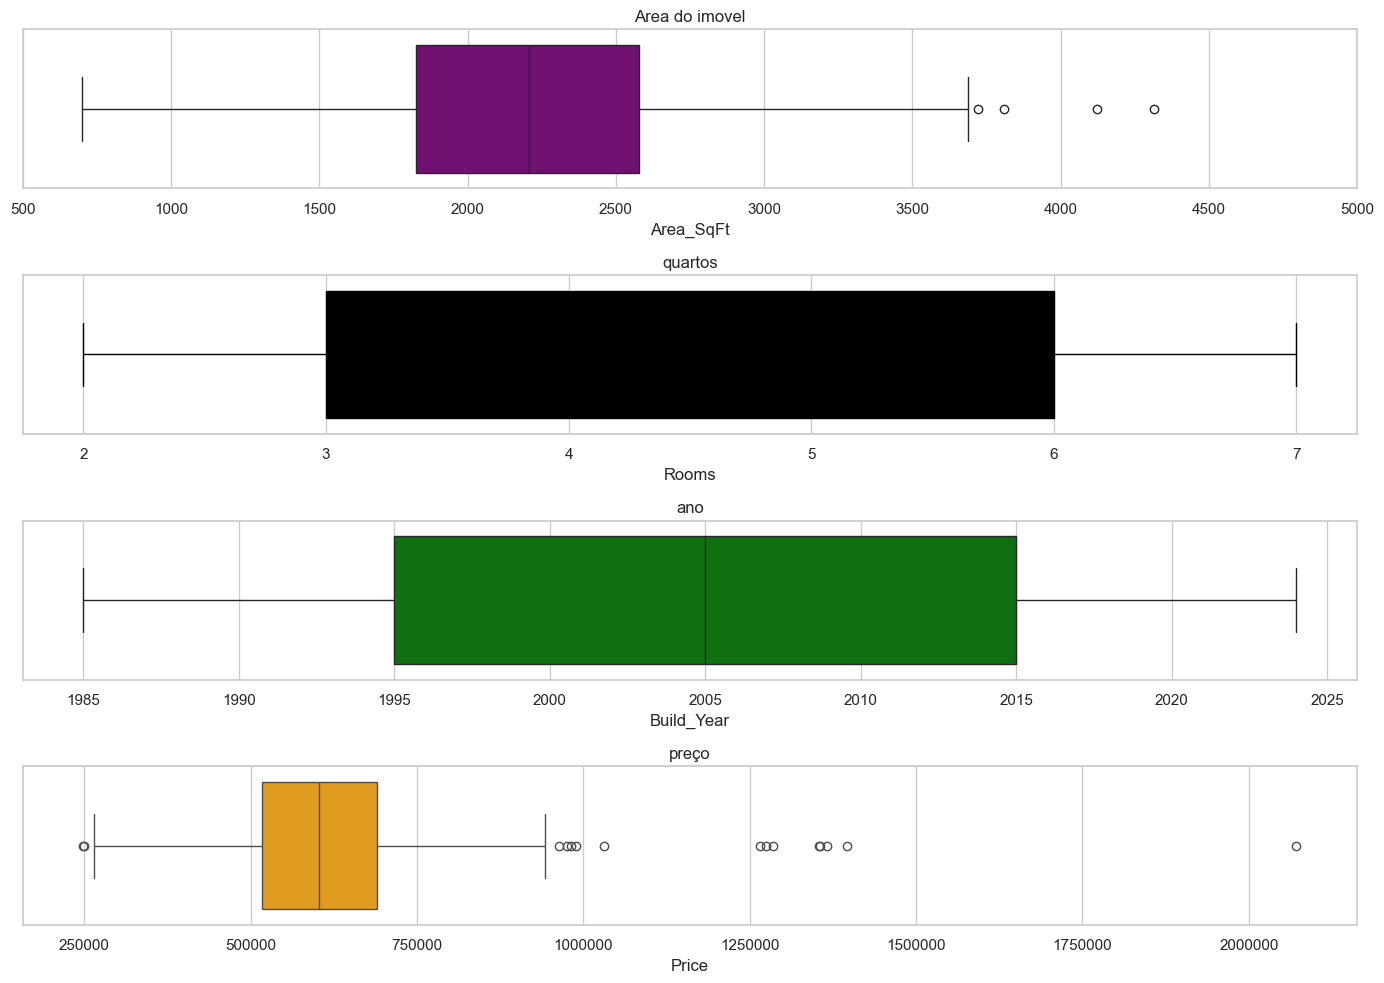

In [17]:
plt.figure(figsize=(14,10))
plt.subplot(4,1,1)
sns.boxplot(data=imob, x='Area_SqFt',   color = 'purple')
plt.xlim(500,5000)
plt.title('Area do imovel')
plt.subplot(4,1,2)
sns.boxplot(data = imob, x = 'Rooms', color = 'black')
plt.title('quartos')
plt.subplot(4,1,3)
sns.boxplot(data = imob, x = 'Build_Year',  color = 'green')
plt.title('ano')
plt.subplot(4,1,4)
sns.boxplot(data = imob, x = 'Price', color='orange')
plt.ticklabel_format(style='plain', axis='x')
plt.title('preço')
plt.tight_layout()
plt.show()

In [18]:
imob['Location'].value_counts


<bound method IndexOpsMixin.value_counts of 0          Jaipur
1          Indore
2          Jaipur
3         Lucknow
4          Jaipur
          ...    
1118      Lucknow
1119        Noida
1120       Kanpur
1121    Prayagraj
1123     Gurugram
Name: Location, Length: 1027, dtype: object>

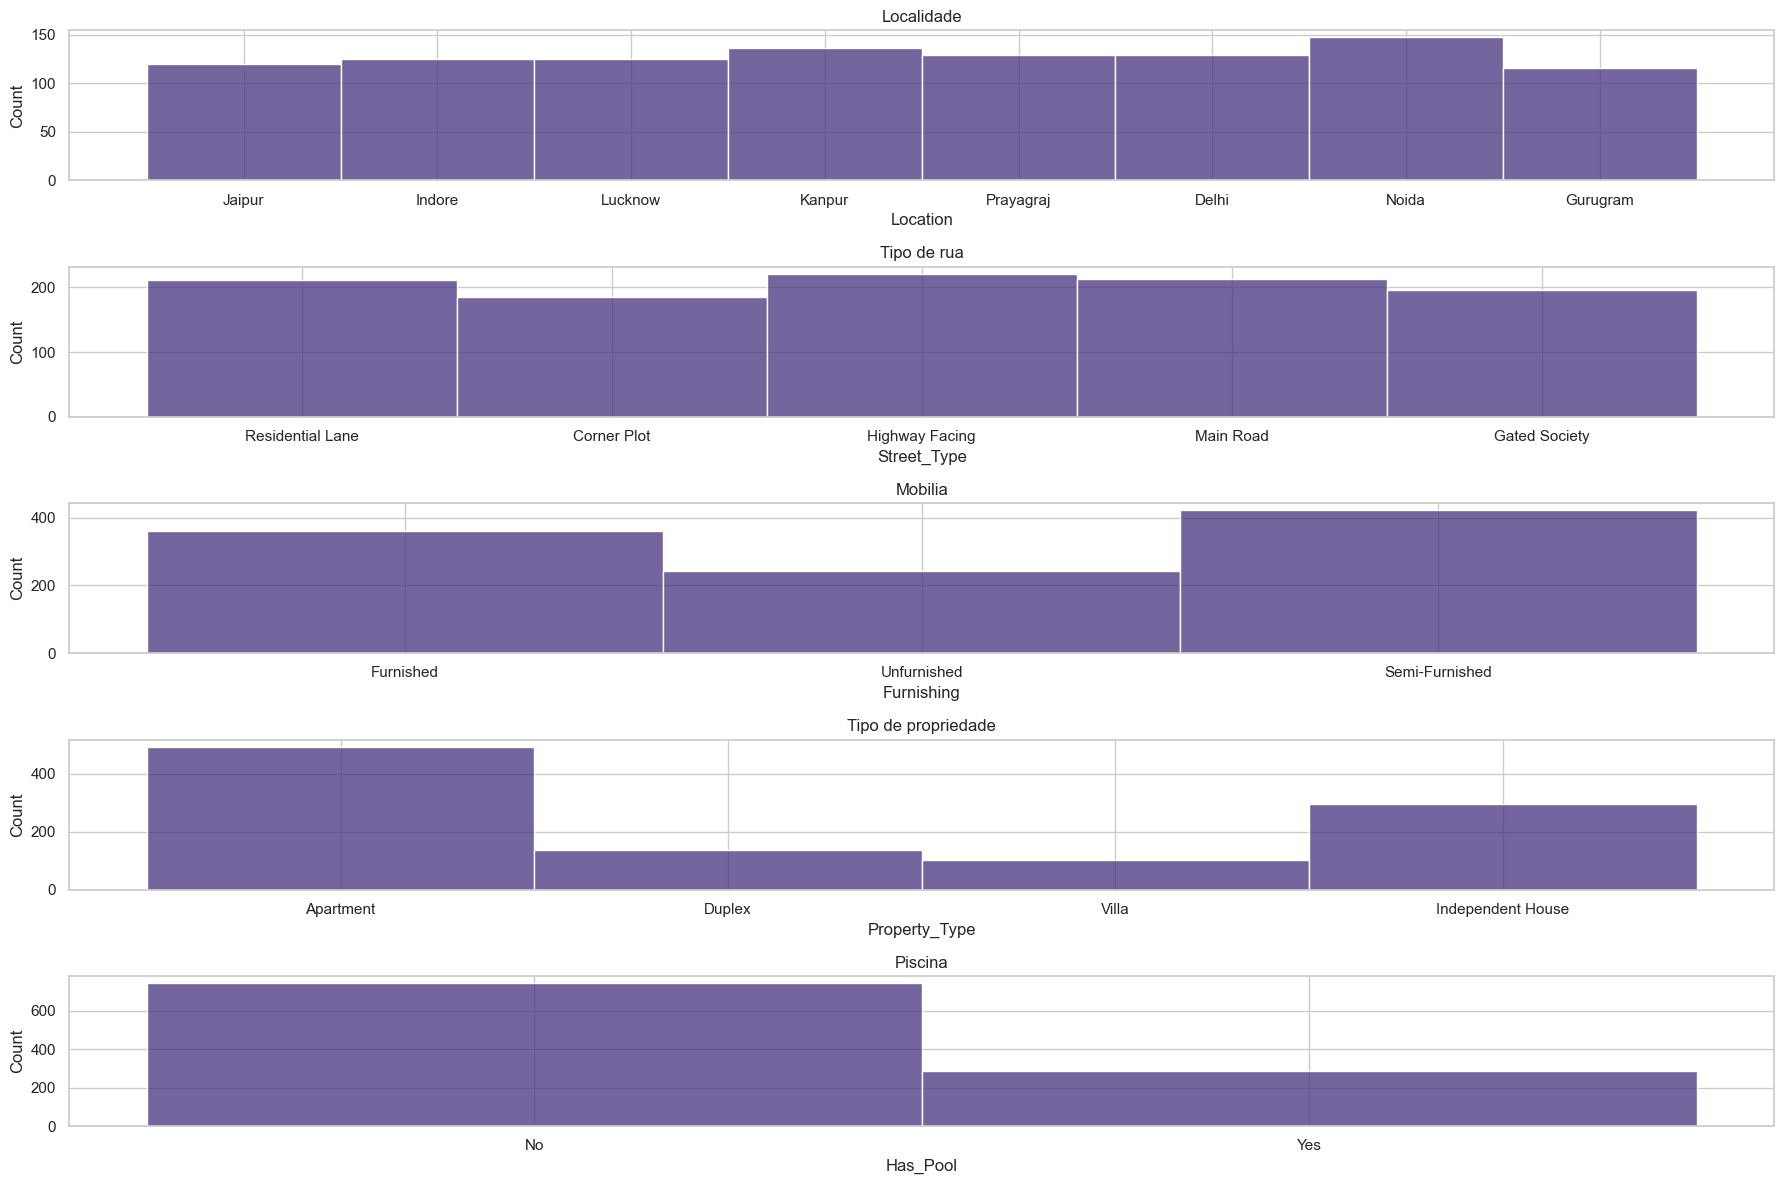

In [19]:
plt.figure(figsize=(18,12))
plt.subplot(5,1,1)
sns.histplot(data=imob, x='Location')
plt.title('Localidade')
plt.subplot(5,1,2)
sns.histplot(data=imob, x='Street_Type')
plt.title('Tipo de rua')
plt.subplot(5,1,3)
sns.histplot(data=imob, x='Furnishing')
plt.title('Mobilia')
plt.subplot(5,1,4)
sns.histplot(data=imob, x='Property_Type')
plt.title('Tipo de propriedade')
plt.subplot(5,1,5)
sns.histplot(data=imob, x='Has_Pool')
plt.title('Piscina')
plt.tight_layout()
plt.show()

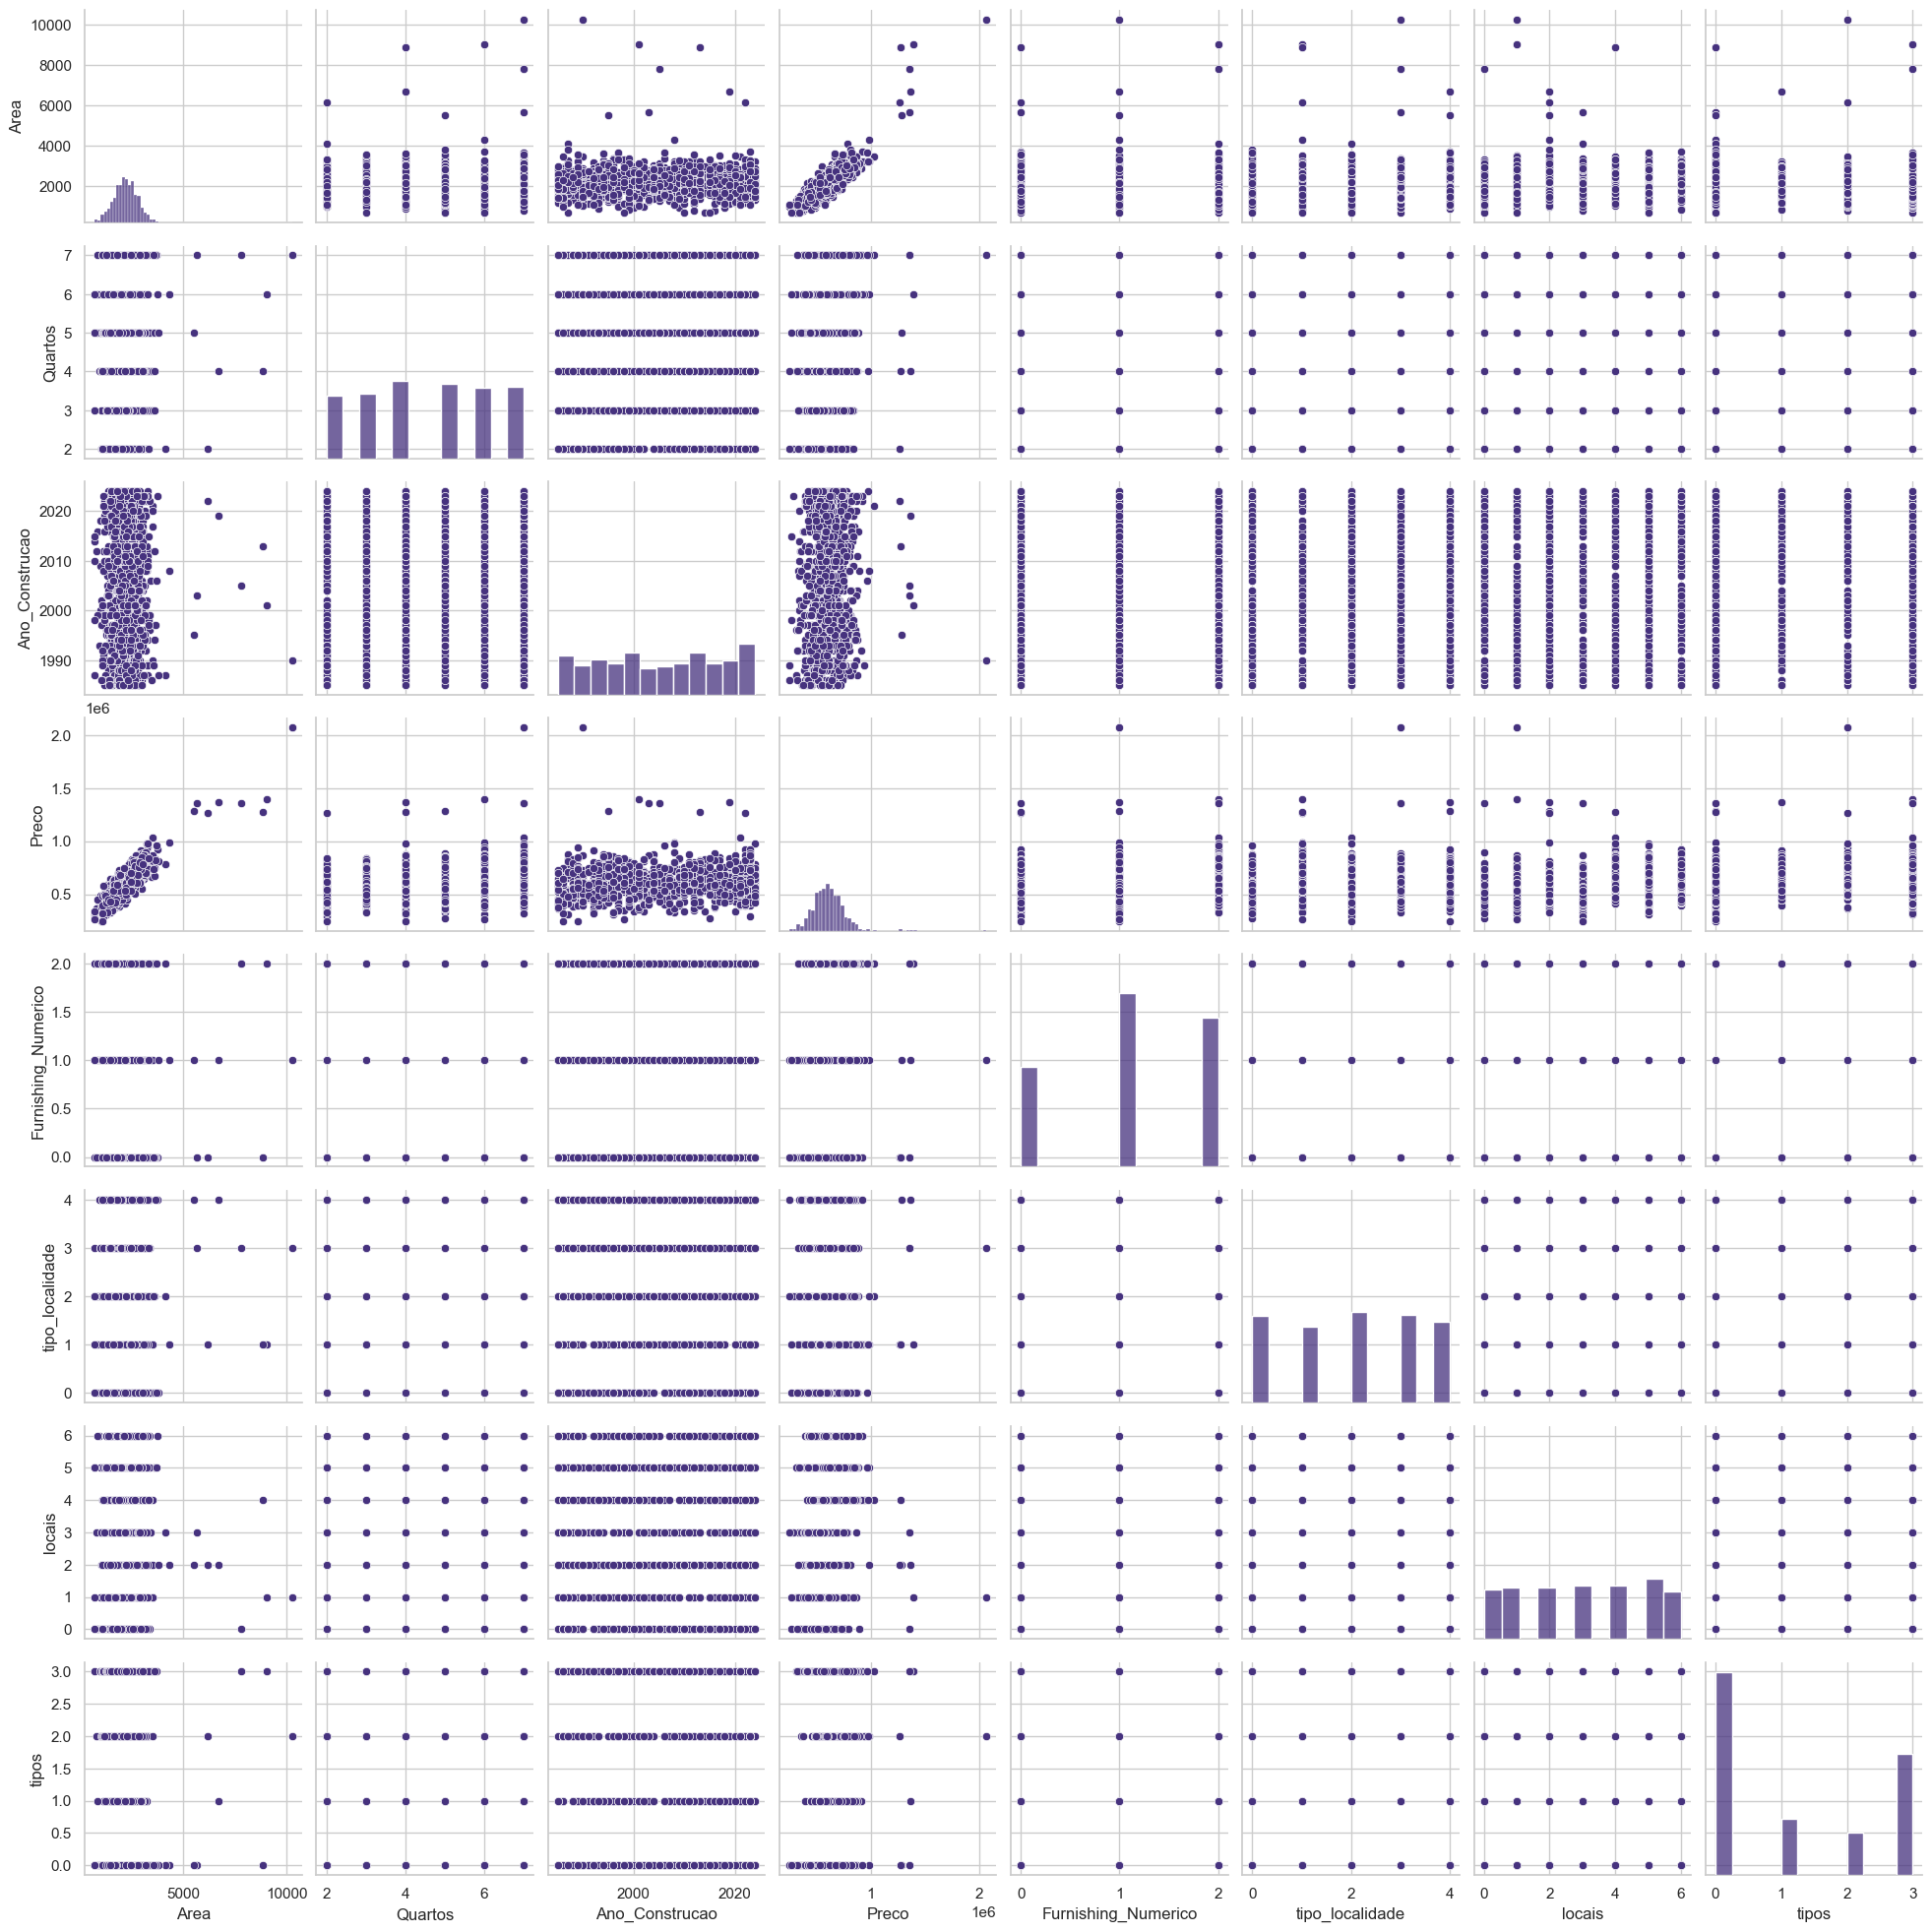

In [43]:
sns.pairplot(data=imob)

In [44]:
# Criamos um dicionário com o mapeamento e aplicamos na coluna
dicionario_mobilia = {
    'Unfurnished': 0,
    'Semi-Furnished': 1,
    'Furnished': 2
}

imob['Furnishing_Numerico'] = imob['Furnishing'].map(dicionario_mobilia)

KeyError: 'Furnishing'

In [ ]:
dic_tipo_localidade = {
    'Residential Lane': 0,
    'Corner Plot': 1,
    'Highway Facing': 2,
    'Main Road': 3,
    'Gated Society': 4
}

dic_locais = {
    'Jaipur': 0,
    'Indore': 1,
    'Lucknow': 2,
    'Prayagraj': 3,
    'Delhi': 4,
    'Noida': 5,
    'Gurugram' : 6    
}

dic_tipo = {
    'Apartment': 0,
    'Duplex': 1,
    'Villa': 2,
    'Independent House': 3
    }

imob['tipo_localidade'] = imob['Street_Type'].map(dic_tipo_localidade)
imob['locais'] = imob['Location'].map(dic_locais)
imob['tipos'] = imob ['Property_Type'].map(dic_tipo)

imob.drop(columns=['Street_Type', 'Location', 'Property_Type'], inplace=True)

In [ ]:
imob.drop(columns=['Furnishing'], inplace=True)


In [ ]:
imob.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Property_Type,Has_Pool,Price,Furnishing_Numerico
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Apartment,No,568486.0,2
1,2353.472711,4.0,2006,Indore,Corner Plot,Apartment,Yes,577214.0,0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Duplex,No,581300.0,1
3,2823.886596,6.0,1993,Lucknow,Main Road,Villa,Yes,794614.0,0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Apartment,No,493086.0,1


In [ ]:
imob.rename(columns={
    'Area_SqFt': 'Area',
    'Rooms': 'Quartos',
    'Build_Year': 'Ano_Construcao',
    'Location': 'Localizacao',
    'Street_Type': 'Tipo_Rua',
    'Furnishing': 'Mobilia',
    'Property_Type': 'Tipo_Imovel',
    'Has_Pool': 'Tem_Piscina',
    'Price': 'Preco'
}, inplace=True)

In [ ]:
imob.head()
    


,Area,Quartos,Ano_Construcao,Tem_Piscina,Preco,Furnishing_Numerico,tipo_localidade,locais,tipos
0,2473.192784,4.0,1992,No,568486.0,2,0,0.0,0
1,2353.472711,4.0,2006,Yes,577214.0,0,1,1.0,0
2,2212.222005,3.0,2012,No,581300.0,1,2,0.0,1
3,2823.886596,6.0,1993,Yes,794614.0,0,3,2.0,2
4,1869.648721,5.0,2012,No,493086.0,1,1,0.0,0


In [53]:
imob.to_csv('imobLimpo.csv', index=False)

In [51]:
dic_pool = {
    'No' : 0,
    'Yes' : 1
    }

imob['Piscina'] = imob ['Tem_Piscina'].map(dic_pool)

imob.drop(columns=['Tem_Piscina'], inplace = True)

In [52]:
imob.head()

,Area,Quartos,Ano_Construcao,Preco,Furnishing_Numerico,tipo_localidade,locais,tipos,Piscina
0,2473.192784,4.0,1992,568486.0,2,0,0.0,0,0
1,2353.472711,4.0,2006,577214.0,0,1,1.0,0,1
2,2212.222005,3.0,2012,581300.0,1,2,0.0,1,0
3,2823.886596,6.0,1993,794614.0,0,3,2.0,2,1
4,1869.648721,5.0,2012,493086.0,1,1,0.0,0,0
